<a href="https://colab.research.google.com/github/joelya9-design/Yield-curve/blob/main/OAT_vs_US_Treasury_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#import necessary add-ins
import pandas as pd
import numpy as np
import pandas_datareader as pdr
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [14]:
#download french and US government bond yields from FRED
OAT_10y=pdr.DataReader('IRLTLT01FRM156N','fred',datetime(2020,1,1),datetime(2026,10,1)).dropna()

us_10y=pdr.DataReader('DGS10','fred',datetime(2020,1,1),datetime(2026,10,1)).dropna()
print(OAT_10y,us_10y)

            IRLTLT01FRM156N
DATE                       
2020-01-01            -0.01
2020-02-01            -0.18
2020-03-01            -0.05
2020-04-01             0.06
2020-05-01            -0.03
...                     ...
2026-04-01             3.73
2026-05-01             3.74
2026-06-01             3.68
2026-07-01             3.85
2026-08-01             4.00

[80 rows x 1 columns]             DGS10
DATE             
2020-01-02   1.88
2020-01-03   1.80
2020-01-06   1.81
2020-01-07   1.83
2020-01-08   1.87
...           ...
2026-09-23   5.11
2026-09-24   5.18
2026-09-25   5.17
2026-09-28   5.24
2026-09-29   5.26

[1687 rows x 1 columns]


In [15]:
#compare most recent 10y yields between US and OAT
print(OAT_10y.iloc[-1])
print(us_10y.iloc[-1])

IRLTLT01FRM156N    4.0
Name: 2026-08-01 00:00:00, dtype: float64
DGS10    5.26
Name: 2026-09-29 00:00:00, dtype: float64


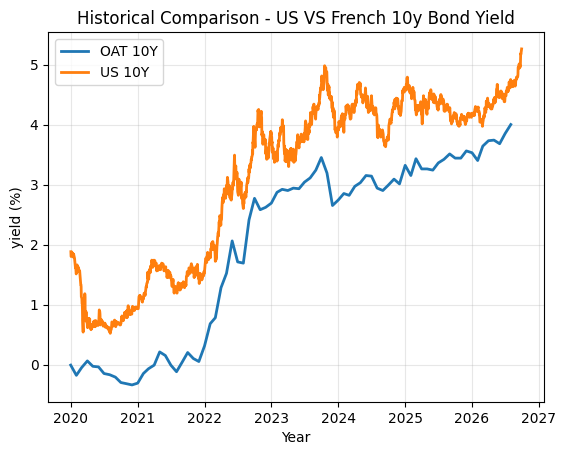

In [21]:
#plot US vs OAT 10y yields
plt.plot(OAT_10y,linewidth=2, label='OAT 10Y')
plt.plot(us_10y,linewidth=2,label='US 10Y')

plt.title('Historical Comparison - US VS French 10y Bond Yield')
plt.xlabel('Year')
plt.ylabel('yield (%)')
plt.legend()
plt.grid(True,alpha=0.3)
plt.savefig('OAT VS US 10Y.png',dpi=150,bbox_inches='tight')
plt.show()


In [27]:
#create an additonal line tracking the credit spread
#combine both series into one DataFrame - pandas aligns on common date
combined=pd.concat([OAT_10y,us_10y],axis=1).dropna()
combined.columns=['OAT_10Y','US_10Y'] #renames colunmns
#pd.concat combine series into single data frame

#calculate spread by creating a new column in 'combined' dataframe
combined['Spread']=combined['OAT_10Y']-combined['US_10Y']
print(combined)

            OAT_10Y  US_10Y  Spread
DATE                               
2020-04-01     0.06    0.62   -0.56
2020-05-01    -0.03    0.64   -0.67
2020-06-01    -0.04    0.66   -0.70
2020-07-01    -0.15    0.69   -0.84
2020-09-01    -0.21    0.68   -0.89
2020-10-01    -0.30    0.68   -0.98
2020-12-01    -0.34    0.92   -1.26
2021-02-01    -0.15    1.09   -1.24
2021-03-01    -0.07    1.45   -1.52
2021-04-01    -0.01    1.69   -1.70
2021-06-01     0.15    1.62   -1.47
2021-07-01    -0.01    1.48   -1.49
2021-09-01     0.04    1.31   -1.27
2021-10-01     0.20    1.48   -1.28
2021-11-01     0.10    1.58   -1.48
2021-12-01     0.05    1.43   -1.38
2022-02-01     0.68    1.81   -1.13
2022-03-01     0.78    1.72   -0.94
2022-04-01     1.28    2.39   -1.11
2022-06-01     2.06    2.94   -0.88
2022-07-01     1.71    2.88   -1.17
2022-08-01     1.69    2.60   -0.91
2022-09-01     2.41    3.26   -0.85
2022-11-01     2.58    4.07   -1.49
2022-12-01     2.62    3.53   -0.91
2023-02-01     2.87    3.39 

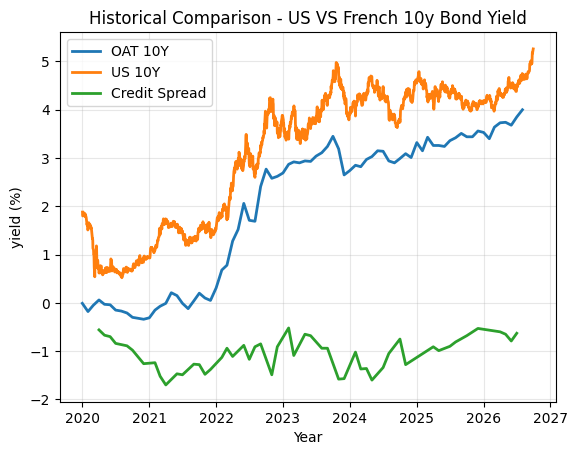

In [29]:
# add the credit spread between the two 10y yields
plt.plot(OAT_10y,linewidth=2, label='OAT 10Y')
plt.plot(us_10y,linewidth=2,label='US 10Y')
plt.plot(combined['Spread'],linewidth=2,label='Credit Spread')

plt.title('Historical Comparison - US VS French 10y Bond Yield')
plt.xlabel('Year')
plt.ylabel('yield (%)')
plt.legend()
plt.grid(True,alpha=0.3)
plt.savefig('OAT VS US 10Y with spread.png',dpi=150,bbox_inches='tight')
plt.show()
